# U.S. Airline Operations & Delay Root-Cause Analytics

## tl;dr
This executed notebook validates the BTS-based flight model, profiles quality, quantifies operations trends and delay drivers, and estimates uncertainty around key comparisons. Results are descriptive and associational, not causal.

## Context & Methods

**Scope:** complete 2023-2025 BTS Reporting Carrier On-Time Performance monthly files.

### Key Assumptions
- One fact row represents one reported scheduled domestic flight record.
- Arrival-delay/on-time metrics use operated, non-diverted flights only.
- A delayed flight has arrival delay of 15+ minutes.
- Carrier and airport comparisons are interpreted only after minimum-volume filtering and are not causal.

## Data

### 1. Load model and validate basic coverage

In [1]:
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parent
DB = ROOT / 'data' / 'processed' / 'airline_operations.duckdb'
CHARTS = ROOT / 'charts'
CHARTS.mkdir(exist_ok=True)
con = duckdb.connect(str(DB), read_only=True)
profile = con.execute('''
SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT flight_key) AS unique_keys,
       MIN(flight_date) AS min_date, MAX(flight_date) AS max_date,
       SUM(cancelled) AS cancellations, SUM(diverted) AS diversions
FROM fact_flights
''').fetchdf()
profile

/Users/shashankpabitwar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/cm/gk1zyspd5gddzb07hjj31v_40000gn/T/matplotlib-7dlgf760 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


,fact_rows,unique_keys,min_date,max_date,cancellations,diversions
0,20928579,20928579,2023-01-01,2025-12-31,287134.0,53309.0


In [2]:
missingness = con.execute('''
SELECT
  AVG(CASE WHEN arrival_delay_minutes IS NULL THEN 1 ELSE 0 END) AS arrival_delay_missing_rate,
  AVG(CASE WHEN distance_miles IS NULL THEN 1 ELSE 0 END) AS distance_missing_rate,
  AVG(CASE WHEN origin = 'Unknown' OR dest = 'Unknown' THEN 1 ELSE 0 END) AS airport_label_unknown_rate
FROM fact_flights
''').fetchdf()
missingness

,arrival_delay_missing_rate,distance_missing_rate,airport_label_unknown_rate
0,0.016267,0.0,0.0


## Results

### 2. Monthly operational trend

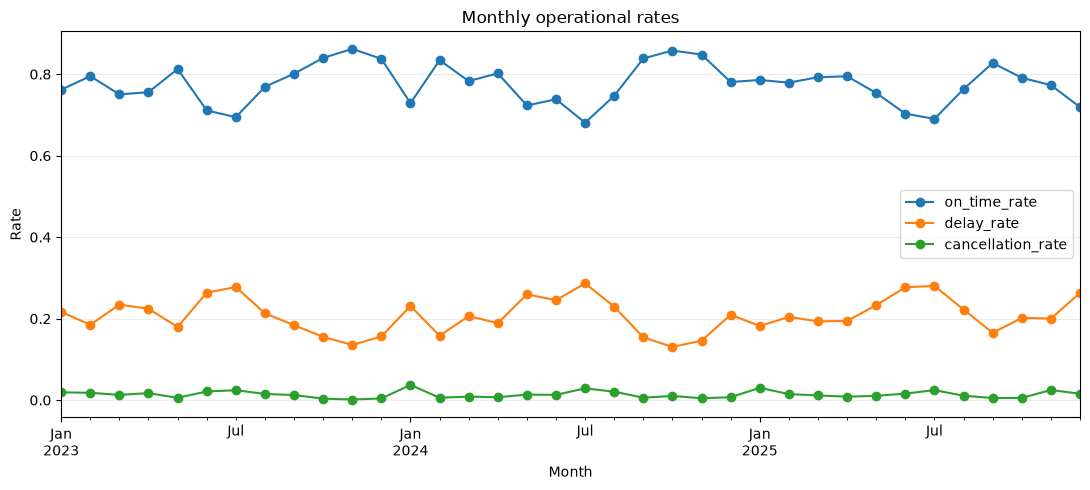

In [3]:
monthly = con.execute('''
SELECT flight_month, COUNT(*) AS scheduled_flights, AVG(arrived_on_time) AS on_time_rate,
       AVG(delayed_flight) AS delay_rate, AVG(cancelled) AS cancellation_rate
FROM fact_flights GROUP BY 1 ORDER BY 1
''').fetchdf()
ax = monthly.plot(x='flight_month', y=['on_time_rate','delay_rate','cancellation_rate'], figsize=(11,5), marker='o')
ax.set(title='Monthly operational rates', xlabel='Month', ylabel='Rate'); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.savefig(CHARTS / 'monthly_operational_rates.png', dpi=160); plt.show()

### 3. Delay-cause contribution

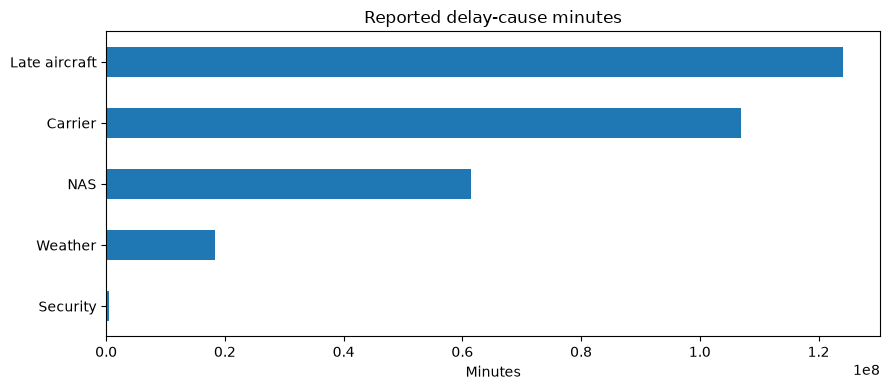

,cause,minutes,share_of_reported_delay_minutes
0,Late aircraft,124146659.0,0.398637
1,Carrier,107011714.0,0.343617
2,NAS,61415753.0,0.197207
3,Weather,18313928.0,0.058806
4,Security,539407.0,0.001732


In [4]:
causes = con.execute('''
SELECT 'Carrier' AS cause, SUM(carrier_delay) AS minutes FROM fact_flights UNION ALL
SELECT 'Weather', SUM(weather_delay) FROM fact_flights UNION ALL
SELECT 'NAS', SUM(nas_delay) FROM fact_flights UNION ALL
SELECT 'Security', SUM(security_delay) FROM fact_flights UNION ALL
SELECT 'Late aircraft', SUM(late_aircraft_delay) FROM fact_flights
ORDER BY minutes DESC
''').fetchdf()
causes['share_of_reported_delay_minutes'] = causes.minutes / causes.minutes.sum()
ax = causes.sort_values('minutes').plot.barh(x='cause', y='minutes', legend=False, figsize=(9,4), color='#1f77b4')
ax.set(title='Reported delay-cause minutes', xlabel='Minutes', ylabel=''); plt.tight_layout()
plt.savefig(CHARTS / 'delay_cause_minutes.png', dpi=160); plt.show()
causes

### 4. Confidence intervals and controlled comparisons

In [5]:
# Wilson confidence intervals for delay rates at high-volume origin airports.
airports = con.execute('''
SELECT origin, origin_city_name, origin_state, COUNT(*) AS flights, SUM(delayed_flight) AS delayed_flights,
       AVG(delayed_flight) AS delay_rate
FROM fact_flights GROUP BY 1,2,3 HAVING COUNT(*) >= 5000
ORDER BY delay_rate DESC LIMIT 20
''').fetchdf()
z = stats.norm.ppf(.975)
p = airports.delay_rate.to_numpy(); n = airports.flights.to_numpy()
den = 1 + z**2/n; center = (p + z**2/(2*n))/den; margin = z*np.sqrt((p*(1-p) + z**2/(4*n))/n)/den
airports['delay_rate_ci_low'] = center-margin; airports['delay_rate_ci_high'] = center+margin
airports.head(10)

,origin,origin_city_name,origin_state,flights,delayed_flights,delay_rate,delay_rate_ci_low,delay_rate_ci_high
0,ASE,"Aspen, CO",CO,22164,6488.0,0.292727,0.286773,0.298753
1,FLL,"Fort Lauderdale, FL",FL,269310,72249.0,0.268274,0.266604,0.269951
2,EGE,"Eagle, CO",CO,10664,2836.0,0.265941,0.257641,0.274411
3,MIA,"Miami, FL",FL,324386,86224.0,0.265807,0.264289,0.267330
4,SFB,"Sanford, FL",FL,29096,7724.0,0.265466,0.260423,0.270571
5,DFW,"Dallas/Fort Worth, TX",TX,914680,238127.0,0.260339,0.259441,0.261239
6,HDN,"Hayden, CO",CO,7183,1831.0,0.254907,0.244962,0.265115
7,MCO,"Orlando, FL",FL,483970,123302.0,0.254772,0.253546,0.256002
8,BQN,"Aguadilla, PR",PR,7641,1912.0,0.250229,0.240644,0.260065
9,CLT,"Charlotte, NC",NC,608080,149103.0,0.245203,0.244123,0.246286


In [6]:
# Comparable carrier performance: route-month fixed comparison cells (at least 100 flights per carrier cell).
comparison = con.execute('''
WITH route_carrier AS (
  SELECT flight_month, route_key, reporting_airline, COUNT(*) AS flights, AVG(delayed_flight) AS delay_rate
  FROM fact_flights GROUP BY 1,2,3
), comparable AS (SELECT * FROM route_carrier WHERE flights >= 100), peer_comparison AS (
  SELECT *, AVG(delay_rate) OVER (PARTITION BY flight_month, route_key) AS route_month_peer_delay_rate
  FROM comparable
)
SELECT reporting_airline, SUM(flights) AS comparable_flights,
       AVG(delay_rate) AS mean_cell_delay_rate,
       AVG(delay_rate - route_month_peer_delay_rate) AS mean_relative_delay_rate
FROM peer_comparison GROUP BY 1 ORDER BY comparable_flights DESC
''').fetchdf()
comparison.head(15)

,reporting_airline,comparable_flights,mean_cell_delay_rate,mean_relative_delay_rate
0,WN,2418827.0,0.210339,0.005374
1,DL,2101344.0,0.172933,-0.006390
2,AA,1903689.0,0.244107,0.004107
3,UA,1315510.0,0.205200,-0.013224
4,OO,657153.0,0.198709,-0.005538
5,YX,386713.0,0.163243,-0.010430
6,B6,327519.0,0.267582,0.018415
7,AS,319140.0,0.214809,0.019323
8,OH,209464.0,0.216187,0.000130
9,MQ,196935.0,0.194843,-0.002125


### 5. Outlier review

In [7]:
outliers = con.execute('''
SELECT delay_severity, COUNT(*) AS flights, AVG(arrival_delay_minutes) AS mean_arrival_delay_minutes
FROM fact_flights GROUP BY 1 ORDER BY mean_arrival_delay_minutes NULLS LAST
''').fetchdf()
outliers

,delay_severity,flights,mean_arrival_delay_minutes
0,On time,16216831,-9.791963
1,15-29,1519587,21.111670
2,30-59,1315560,42.124515
3,60-119,914898,83.624529
4,120+,621258,237.301348
5,Unknown,2,NaN
6,Not applicable,340443,NaN


## Takeaways

- Use the saved charts and confidence intervals alongside minimum-flight thresholds when prioritizing operational investigations.
- Check carrier performance within comparable route-month cells; network mix can otherwise dominate simple rankings.
- Treat weather, NAS, and late-aircraft fields as reported delay categories, not independent causal mechanisms.
- Follow the executive memo for the final business recommendations after the full pipeline has produced reconciled outputs.